In [102]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import sqlite3

df_2015 = pd.read_csv('2015.csv')
df_2016 = pd.read_csv('2016.csv')
df_2017 = pd.read_csv('2017.csv')
df_2018 = pd.read_csv('2018.csv')
df_2019 = pd.read_csv('2019.csv')

In [103]:
df_2015.head()


,Country,Region,Happiness Rank,Happiness Score,Standard Error,Economy (GDP per Capita),Family,Health (Life Expectancy),Freedom,Trust (Government Corruption),Generosity,Dystopia Residual
0,Switzerland,Western Europe,1,7.587,0.03411,1.39651,1.34951,0.94143,0.66557,0.41978,0.29678,2.51738
1,Iceland,Western Europe,2,7.561,0.04884,1.30232,1.40223,0.94784,0.62877,0.14145,0.43630,2.70201
2,Denmark,Western Europe,3,7.527,0.03328,1.32548,1.36058,0.87464,0.64938,0.48357,0.34139,2.49204
3,Norway,Western Europe,4,7.522,0.03880,1.45900,1.33095,0.88521,0.66973,0.36503,0.34699,2.46531
4,Canada,North America,5,7.427,0.03553,1.32629,1.32261,0.90563,0.63297,0.32957,0.45811,2.45176


In [104]:
df_2015_clean = df_2015[['Country', 'Happiness Score', 'Economy (GDP per Capita)','Health (Life Expectancy)']].copy()
df_2015_clean.columns = ['country', 'happiness_score', 'gdp', 'health']
df_2015_clean['year'] = 2015
df_2015_clean.head()

,country,happiness_score,gdp,health,year
0,Switzerland,7.587,1.39651,0.94143,2015
1,Iceland,7.561,1.30232,0.94784,2015
2,Denmark,7.527,1.32548,0.87464,2015
3,Norway,7.522,1.45900,0.88521,2015
4,Canada,7.427,1.32629,0.90563,2015


In [105]:
df_2016.head()
df_2016_clean = df_2016[['Country', 'Happiness Score', 'Economy (GDP per Capita)','Health (Life Expectancy)']].copy()
df_2016_clean.columns = ['country', 'happiness_score', 'gdp', 'health']
df_2016_clean['year'] = 2016
df_2016_clean.head()

,country,happiness_score,gdp,health,year
0,Denmark,7.526,1.44178,0.79504,2016
1,Switzerland,7.509,1.52733,0.86303,2016
2,Iceland,7.501,1.42666,0.86733,2016
3,Norway,7.498,1.57744,0.79579,2016
4,Finland,7.413,1.40598,0.81091,2016


In [106]:
df_2017.head()
df_2017_clean = df_2017[['Country', 'Happiness.Score', 'Economy..GDP.per.Capita.','Health..Life.Expectancy.']].copy()
df_2017_clean.columns = ['country', 'happiness_score', 'gdp', 'health']
df_2017_clean['year'] = 2017
df_2017_clean.head()

,country,happiness_score,gdp,health,year
0,Norway,7.537,1.616463,0.796667,2017
1,Denmark,7.522,1.482383,0.792566,2017
2,Iceland,7.504,1.480633,0.833552,2017
3,Switzerland,7.494,1.564980,0.858131,2017
4,Finland,7.469,1.443572,0.809158,2017


In [107]:
df_2018.head()
df_2018_clean = df_2018[['Country or region', 'Score', 'GDP per capita','Healthy life expectancy']].copy()
df_2018_clean.columns = ['country', 'happiness_score', 'gdp', 'health']
df_2018_clean['year'] = 2018
df_2018_clean.head()

,country,happiness_score,gdp,health,year
0,Finland,7.632,1.305,0.874,2018
1,Norway,7.594,1.456,0.861,2018
2,Denmark,7.555,1.351,0.868,2018
3,Iceland,7.495,1.343,0.914,2018
4,Switzerland,7.487,1.420,0.927,2018


In [108]:
df_2019.head()
df_2019_clean = df_2019[['Country or region', 'Score', 'GDP per capita','Healthy life expectancy']].copy()
df_2019_clean.columns = ['country', 'happiness_score', 'gdp', 'health']
df_2019_clean['year'] = 2019
df_2019_clean.head()

,country,happiness_score,gdp,health,year
0,Finland,7.769,1.340,0.986,2019
1,Denmark,7.600,1.383,0.996,2019
2,Norway,7.554,1.488,1.028,2019
3,Iceland,7.494,1.380,1.026,2019
4,Netherlands,7.488,1.396,0.999,2019


In [109]:
df_all = pd.concat([df_2015_clean, df_2016_clean, df_2017_clean, df_2018_clean, df_2019_clean])
print(df_all.shape)
df_all.head()

(782, 5)


,country,happiness_score,gdp,health,year
0,Switzerland,7.587,1.39651,0.94143,2015
1,Iceland,7.561,1.30232,0.94784,2015
2,Denmark,7.527,1.32548,0.87464,2015
3,Norway,7.522,1.45900,0.88521,2015
4,Canada,7.427,1.32629,0.90563,2015


In [110]:
conn = sqlite3.connect('happiness.db')
df_all.to_sql('happiness', conn, if_exists='replace', index=False)
print('Loaded!')

Loaded!


The happiest top 3 countries each year?

In [111]:
query = """
SELECT country, happiness_score, year
FROM happiness
WHERE year = 2015
ORDER BY happiness_score DESC
LIMIT 3
"""
result = pd.read_sql_query(query, conn)
result

,country,happiness_score,year
0,Switzerland,7.587,2015
1,Iceland,7.561,2015
2,Denmark,7.527,2015


In [112]:
query = """
SELECT country, happiness_score, year,
       RANK() OVER (PARTITION BY year ORDER BY happiness_score DESC) as rank
FROM happiness
"""
result = pd.read_sql_query(query, conn)
result.head(20)
result[result['rank'] <= 3]

,country,happiness_score,year,rank
0,Switzerland,7.587,2015,1
1,Iceland,7.561,2015,2
2,Denmark,7.527,2015,3
158,Denmark,7.526,2016,1
159,Switzerland,7.509,2016,2
160,Iceland,7.501,2016,3
315,Norway,7.537,2017,1
316,Denmark,7.522,2017,2
317,Iceland,7.504,2017,3
470,Finland,7.632,2018,1


In [113]:
query = """
SELECT country, happiness_score, year,
       RANK() OVER (PARTITION BY year ORDER BY happiness_score ASC) as rank
FROM happiness
"""
result = pd.read_sql_query(query, conn)
result.head(20)
result[result['rank'] <= 3]

,country,happiness_score,year,rank
0,Togo,2.839,2015,1
1,Burundi,2.905,2015,2
2,Syria,3.006,2015,3
158,Burundi,2.905,2016,1
159,Syria,3.069,2016,2
160,Togo,3.303,2016,3
315,Central African Republic,2.693,2017,1
316,Burundi,2.905,2017,2
317,Tanzania,3.349,2017,3
470,Burundi,2.905,2018,1


In [114]:
query = """
SELECT country, happiness_score, year
FROM happiness
WHERE year = 2017 AND country = 'Syria'
ORDER BY happiness_score DESC
"""
result = pd.read_sql_query(query, conn)
result

,country,happiness_score,year
0,Syria,3.462,2017


In [115]:
query = """
SELECT country, happiness_score, year
FROM happiness
WHERE country = 'Turkey' OR country = 'Qatar'
ORDER BY year ASC
"""
result = pd.read_sql_query(query, conn)
result

,country,happiness_score,year
0,Qatar,6.611,2015
1,Turkey,5.332,2015
2,Qatar,6.375,2016
3,Turkey,5.389,2016
4,Qatar,6.375,2017
5,Turkey,5.500,2017
6,Qatar,6.374,2018
7,Turkey,5.483,2018
8,Qatar,6.374,2019
9,Turkey,5.373,2019


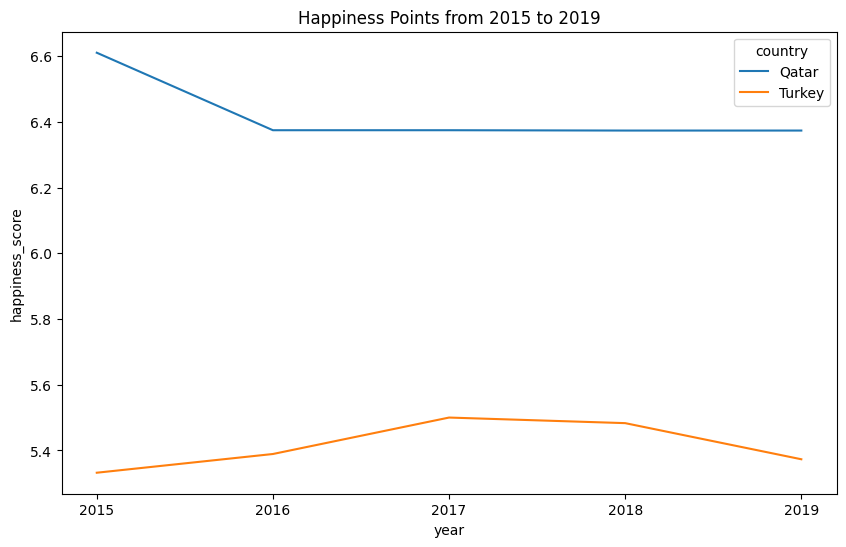

In [116]:
plt.figure(figsize=(10, 6))
sns.lineplot(x='year', y='happiness_score', hue= 'country', data=result)
plt.title('Happiness Points from 2015 to 2019')
plt.xticks([2015, 2016, 2017, 2018, 2019])
plt.show()

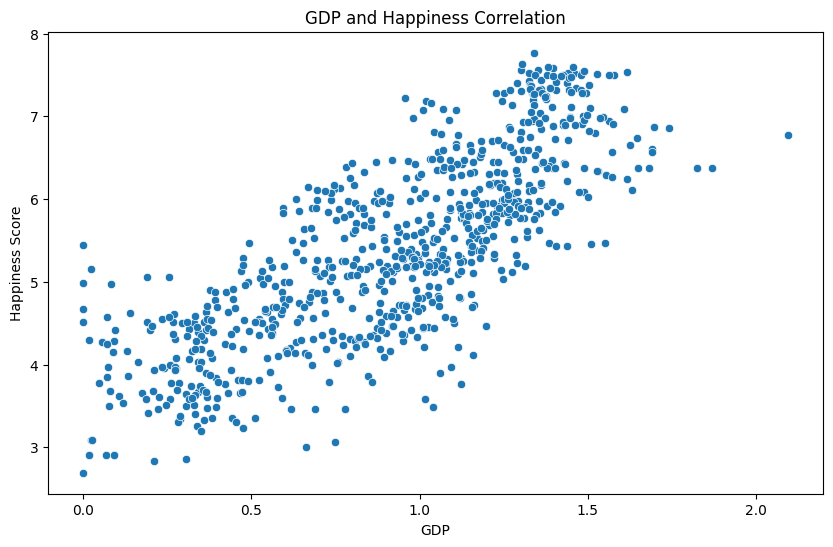

In [117]:
plt.figure(figsize=(10,6))
sns.scatterplot(x=df_all['gdp'], y=df_all['happiness_score'])
plt.title('GDP and Happiness Correlation')
plt.xlabel('GDP')
plt.ylabel('Happiness Score')
plt.show()

In [118]:
correlation = df_all['gdp'].corr(df_all['happiness_score'])
print(f'Correlation: {correlation:.2f}')

Correlation: 0.79


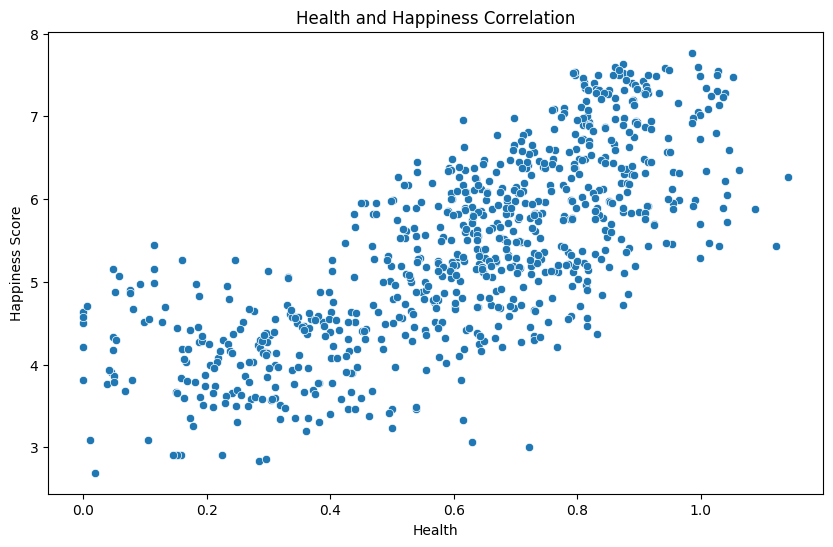

In [119]:
plt.figure(figsize=(10,6))
sns.scatterplot(x=df_all['health'], y=df_all['happiness_score'])
plt.title('Health and Happiness Correlation')
plt.xlabel('Health')
plt.ylabel('Happiness Score')
plt.show()

In [120]:
correlation = df_all['health'].corr(df_all['happiness_score'])
print(f'Correlation: {correlation:.2f}')

Correlation: 0.74


In [121]:
print(f'GDP vs Happiness correlation: {df_all["gdp"].corr(df_all["happiness_score"]):.2f}')
print(f'Health vs Happiness correlation: {df_all["health"].corr(df_all["happiness_score"]):.2f}')

GDP vs Happiness correlation: 0.79
Health vs Happiness correlation: 0.74


In this project, I analyzed the happiness scores of countries from 2015 
to 2019 and investigated the relationship between health, GDP, and 
happiness score. I also compared Qatar and Turkey over time.

Key findings:
- Scandinavian countries consistently rank highest, while African 
  countries rank lowest in happiness.
- Syria showed improvement since 2017 — one possible reason could be 
  the gradual end of the civil war.
- Qatar and Turkey were closest in 2017, but Turkey declined afterward 
  while Qatar remained stable.
- There is a strong positive correlation between GDP and happiness (0.79). 
  Health also shows a strong correlation (0.74), though slightly weaker.
- Note: Correlation does not imply causation — higher GDP may not 
  directly cause happiness.

Next steps: Investigate other factors affecting happiness beyond GDP 
and health, such as freedom, generosity, and government trust.